## 匯入套件

匯入資料處理、視覺化工具，以及三種分類演算法（Logistic Regression、KNN、Random Forest）。

In [1]:
#Import necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Set the default Matplotlib plotting style
plt.style.use("default")

#Inline plots appear in the notebook
%matplotlib inline

## Machine learning models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

## Model evaluation tools
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import RocCurveDisplay

from sklearn import set_config
set_config(display='text')


## 讀取資料

讀入UCI心臟病資料集，共14個屬性——<br>
13個特徵（年齡、性別、血壓等臨床數值）
與1個預測目標（target：是否有心臟病）。

In [2]:
df = pd.read_csv("data/heart-disease-UCI.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


## 探索性資料分析 (Exploratory Data Analysis, EDA)

依以下檢查清單進行資料探索：定義問題與假設、理解資料型態、
檢查缺失值、偵測離群值、探索特徵工程的可能性。

### 檢查目標變數分布

target（1=有心臟病、0=無心臟病）分布：<br>
1類165筆、0類138筆（約54.5% vs 45.5%），
分布相當平衡，不需額外處理類別不平衡問題。

In [3]:
df.target.value_counts()

target
1    165
0    138
Name: count, dtype: int64

In [4]:
df.target.value_counts(normalize=True)

target
1    0.544554
0    0.455446
Name: proportion, dtype: float64

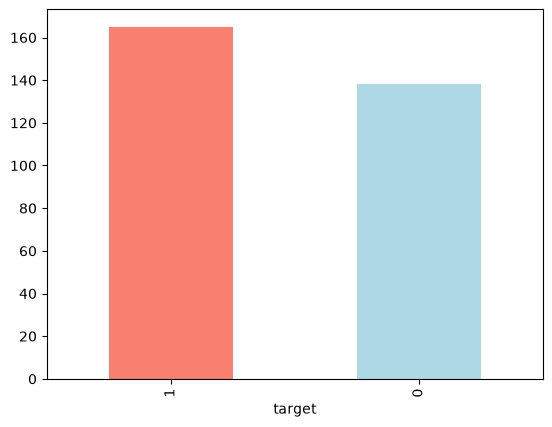

In [5]:
# 以長條圖視覺化目標變數（target）的分布
df.target.value_counts().plot(kind="bar", color=["salmon", "lightblue"]);

### 檢查資料狀況

使用 `.info()` 確認欄位型態與缺失值，全部欄位皆為數值型態，無缺失值。
使用 `.describe()` 觀察各欄位的統計分布。

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [7]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


### 檢查性別與心臟病的關係

用 `pd.crosstab()` 交叉比對 target 與 sex（1=男性、0=女性），
觀察到女性罹病比例約75%，男性約50%，平均約62.5%。
這個簡單的性別基準，可作為後續機器學習模型表現的比較基準。

In [8]:
df.sex.value_counts()

sex
1    207
0     96
Name: count, dtype: int64

In [9]:
# 交叉比對 target 與 sex，查看兩性各自的心臟病人數分布
pd.crosstab(df.target, df.sex)

sex,0,1
target,,
0,24,114
1,72,93


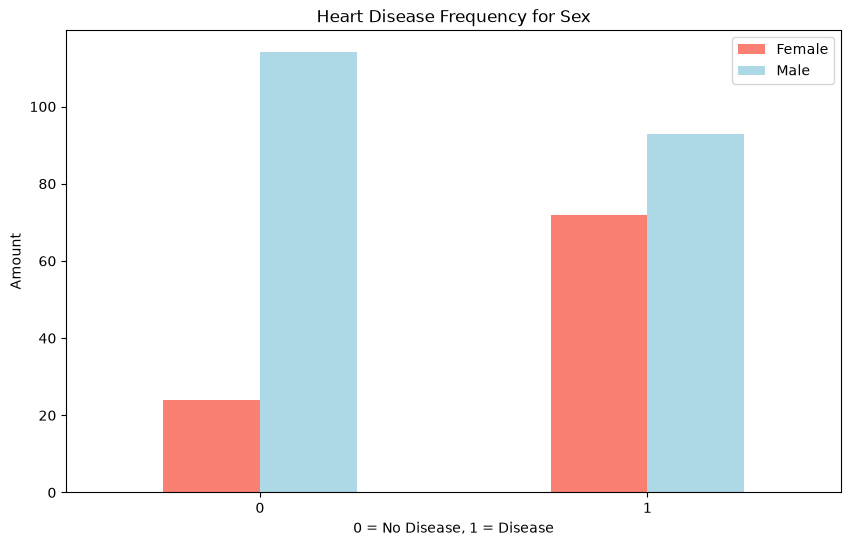

In [10]:
# 依性別繪製心臟病分布長條圖
pd.crosstab(df.target, df.sex).plot(
    kind="bar", 
    figsize=(10,6),
    color=["salmon", "lightblue"]
    )
plt.title("Heart Disease Frequency for Sex")
plt.xlabel("0 = No Disease, 1 = Disease")
plt.ylabel("Amount")
plt.legend(["Female", "Male"])
plt.xticks(rotation=0); 

### 年齡與最大心率對心臟病的關係

用散佈圖觀察年齡（age）與運動時最大心率（thalach），
依 target 分色呈現。<br>
觀察到年輕族群的最大心率普遍較高，
年長族群中罹病比例看起來較高，但年長者樣本數也較多，
需留意這只是初步觀察，非絕對因果關係。

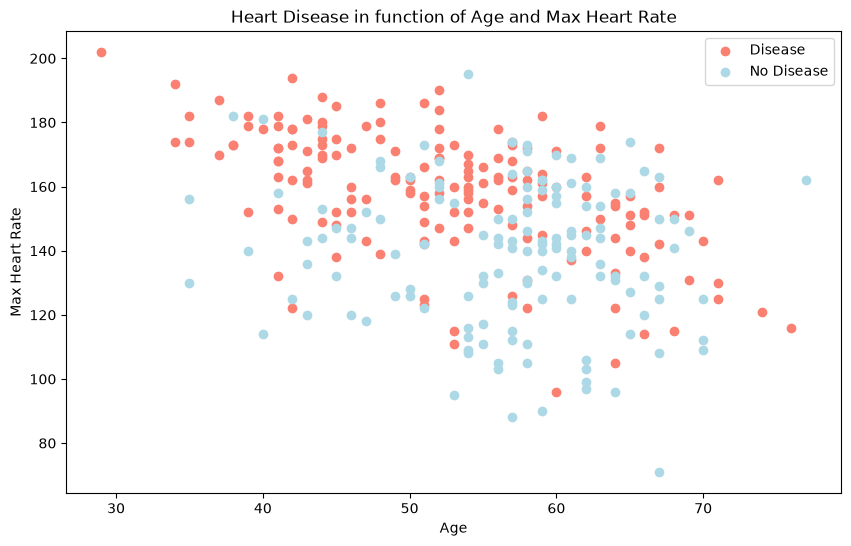

In [11]:
plt.figure(figsize=(10,6))

# 有心臟病的樣本（target=1），用鮭魚色標示
plt.scatter(df.age[df.target==1], 
            df.thalach[df.target==1], 
            c="salmon")

# 沒有心臟病的樣本（target=0），用淺藍色標示
plt.scatter(df.age[df.target==0], 
            df.thalach[df.target==0], 
            c="lightblue")

plt.title("Heart Disease in function of Age and Max Heart Rate")
plt.xlabel("Age")
plt.legend(["Disease", "No Disease"])
plt.ylabel("Max Heart Rate");

#### 年齡分布

用直方圖檢視年齡分布，略為右偏，接近常態分布。

<Axes: ylabel='Frequency'>

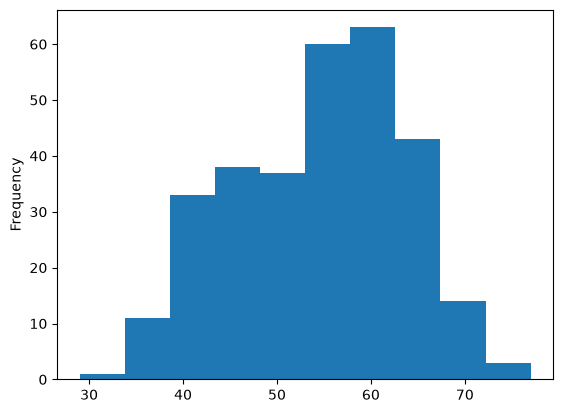

In [12]:
df.age.plot.hist()

In [13]:
pd.crosstab(df.cp, df.target)

target,0,1
cp,,
0,104,39
1,9,41
2,18,69
3,7,16


### 依胸痛類型看心臟病頻率

交叉比對胸痛類型（cp）與 target。觀察到反直覺現象：<br>
1. 典型心絞痛（cp=0）多數反而沒有心臟病。<br>
2. 非心絞痛（cp=2）多數反而有心臟病，關係比預期複雜。

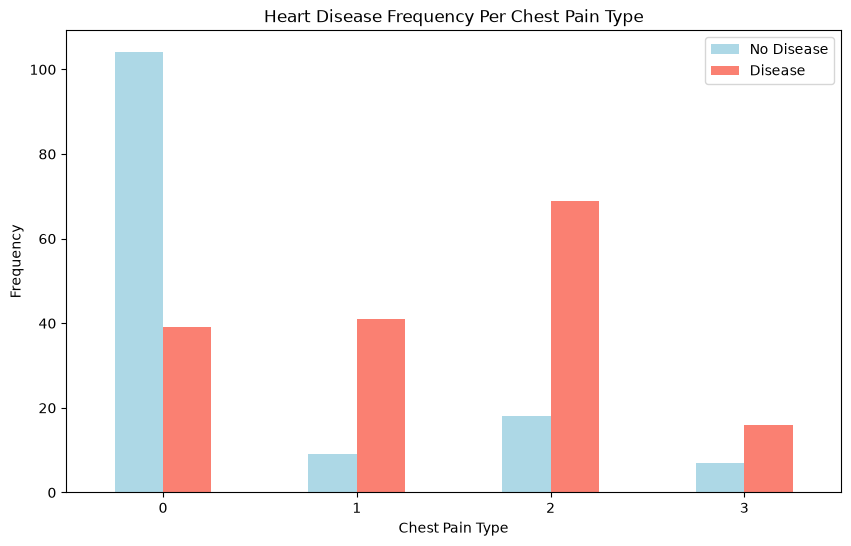

In [14]:
# 交叉比對胸痛類型(cp)與target，並繪製長條圖
pd.crosstab(df.cp, df.target).plot(
    kind="bar", 
    figsize=(10,6),
    color=["lightblue", "salmon"]
)
plt.title("Heart Disease Frequency Per Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Frequency")
plt.legend(["No Disease", "Disease"])
plt.xticks(rotation = 0);

### 檢視變數間的相關性

計算所有變數兩兩之間的相關係數（corr matrix），
快速掌握哪些特徵可能與心臟病（target）有較強關聯，
作為後續模型訓練前的初步線索。

In [15]:
# 計算所有變數兩兩之間的相關係數
df.corr()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.098447,-0.068653,0.279351,0.213678,0.121308,-0.116211,-0.398522,0.096801,0.210013,-0.168814,0.276326,0.068001,-0.225439
sex,-0.098447,1.000000,-0.049353,-0.056769,-0.197912,0.045032,-0.058196,-0.044020,0.141664,0.096093,-0.030711,0.118261,0.210041,-0.280937
cp,-0.068653,-0.049353,1.000000,0.047608,-0.076904,0.094444,0.044421,0.295762,-0.394280,-0.149230,0.119717,-0.181053,-0.161736,0.433798
trestbps,0.279351,-0.056769,0.047608,1.000000,0.123174,0.177531,-0.114103,-0.046698,0.067616,0.193216,-0.121475,0.101389,0.062210,-0.144931
chol,0.213678,-0.197912,-0.076904,0.123174,1.000000,0.013294,-0.151040,-0.009940,0.067023,0.053952,-0.004038,0.070511,0.098803,-0.085239
fbs,0.121308,0.045032,0.094444,0.177531,0.013294,1.000000,-0.084189,-0.008567,0.025665,0.005747,-0.059894,0.137979,-0.032019,-0.028046
restecg,-0.116211,-0.058196,0.044421,-0.114103,-0.151040,-0.084189,1.000000,0.044123,-0.070733,-0.058770,0.093045,-0.072042,-0.011981,0.137230
thalach,-0.398522,-0.044020,0.295762,-0.046698,-0.009940,-0.008567,0.044123,1.000000,-0.378812,-0.344187,0.386784,-0.213177,-0.096439,0.421741
exang,0.096801,0.141664,-0.394280,0.067616,0.067023,0.025665,-0.070733,-0.378812,1.000000,0.288223,-0.257748,0.115739,0.206754,-0.436757
oldpeak,0.210013,0.096093,-0.149230,0.193216,0.053952,0.005747,-0.058770,-0.344187,0.288223,1.000000,-0.577537,0.222682,0.210244,-0.430696


<Axes: >

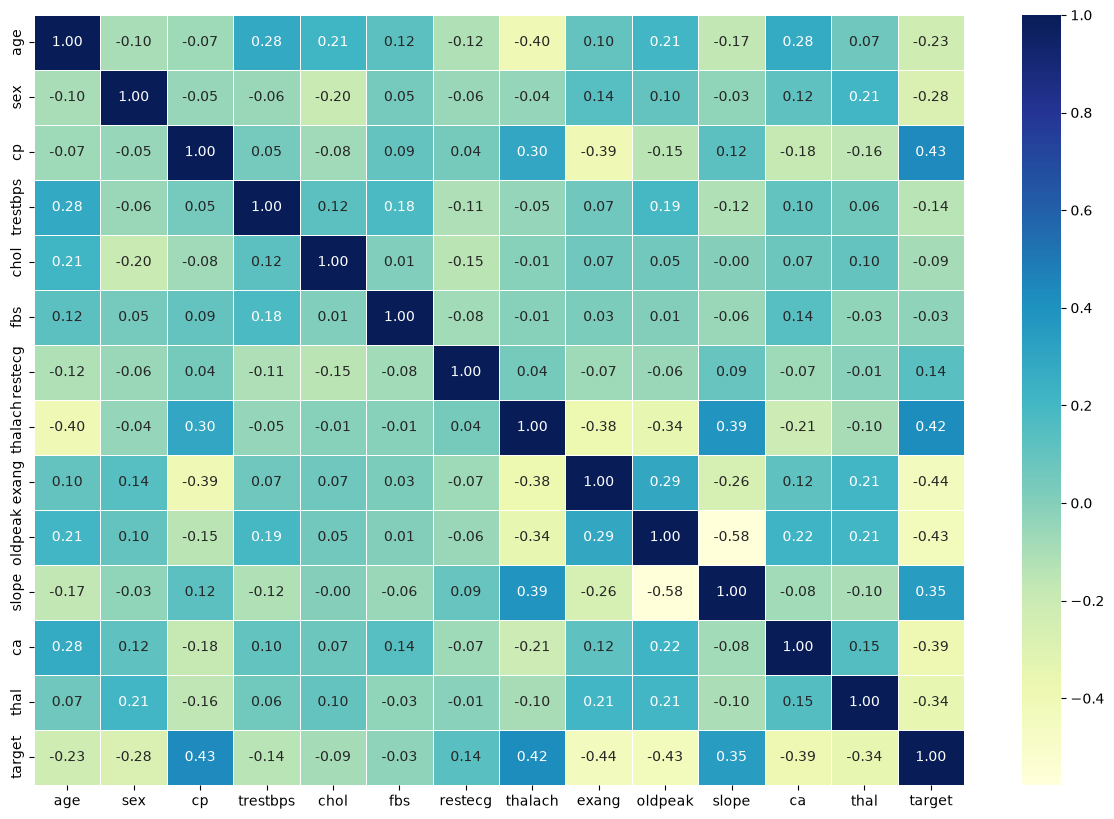

In [16]:
# 用熱力圖呈現相關係數矩陣，數字越接近1（深色）代表正相關越強
corr_matrix = df.corr()
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix,
            annot=True,        # 在每格顯示數值
            linewidths=0.5,    # 格線寬度
            fmt=".2f",         # 數值顯示到小數點後2位
            cmap="YlGnBu")     # 配色方案

## EDA 小結

除了性別這項基準估計外，其餘特徵分布相當平均，未發現明顯缺失值或離群值。
接下來將進入模型訓練階段。

## 建立模型

### 切分特徵與目標變數、訓練集與測試集

In [17]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [18]:
# 移除target欄位作為特徵(X)，取出target作為預測目標(y)
X = df.drop("target", axis=1)
y = df["target"]

In [19]:
# 設定隨機種子確保結果可重現，以8:2比例切分訓練集與測試集
np.random.seed(42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

確認切分後訓練集242筆、測試集61筆，準備開始建立模型。

## 建立三種模型並比較表現

將三種分類演算法（KNN、Logistic Regression、Random Forest）存進字典，
撰寫共用函式批次訓練並計算各模型在測試集上的準確率。

In [20]:
# 建立模型字典
models = {"KNN": KNeighborsClassifier(),
          "Logistic Regression": LogisticRegression(), 
          "Random Forest": RandomForestClassifier()
          }
def fit_and_score(models, X_train, X_test, y_train, y_test):
    """
    訓練並評估多個機器學習模型。
    models : 存放不同scikit-learn模型的字典
    X_train, X_test : 訓練/測試集特徵
    y_train, y_test : 訓練/測試集標籤
    """
    np.random.seed(42)
    model_scores = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        model_scores[name] = model.score(X_test, y_test)
    return model_scores

In [21]:
model_scores = fit_and_score(models=models,
                             X_train=X_train,
                             X_test=X_test,
                             y_train=y_train,
                             y_test=y_test)
model_scores

c:\Users\ouziling\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'KNN': 0.6885245901639344,
 'Logistic Regression': 0.8852459016393442,
 'Random Forest': 0.8360655737704918}

### 基準模型比較

將三個模型的準確率轉成DataFrame並畫成長條圖，方便比較。
Logistic Regression（88.5%）與 Random Forest（83.6%）表現明顯優於 KNN（68.9%），
但都尚未達到一開始設定的95%目標，接下來需要進一步調整。

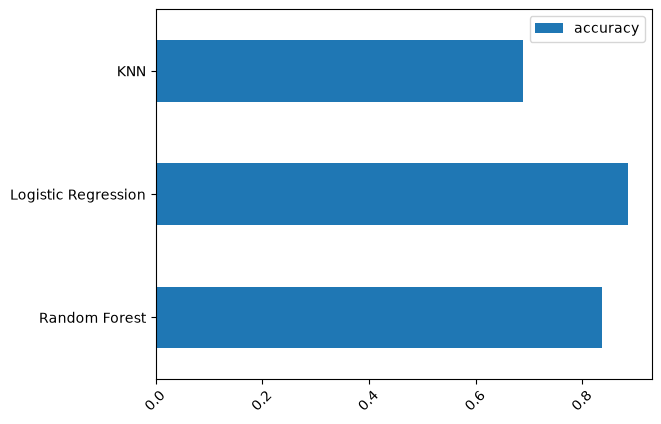

In [22]:
# 轉置後畫成長條圖，方便並排比較三個模型的準確率
# .iloc[::-1] 維持原本清單順序，但視覺上倒過來
model_compare = pd.DataFrame(model_scores, index=['accuracy'])
model_compare.T.iloc[::-1].plot.barh() 
plt.xticks(rotation=45);

## 超參數調校與交叉驗證

依序調整三個模型的超參數，並使用交叉驗證評估表現。

### 調校 KNN 的鄰居數量

依序調整KNN的鄰居數量（n_neighbors，1到20），
分別記錄訓練集與測試集的準確率，繪製折線圖找出最佳設定。

In [23]:
train_scores = []
test_scores = []
neighbors = range(1, 21)  # 測試1到20個鄰居

knn = KNeighborsClassifier() 

for i in neighbors:               # i 依序是 1, 2, ..., 20
    knn.set_params(n_neighbors=i) # 這輪要用幾個鄰居
    knn.fit(X_train, y_train)     # 訓練模型
    train_scores.append(knn.score(X_train, y_train))
    test_scores.append(knn.score(X_test, y_test))


In [24]:
train_scores

[1.0,
 0.8099173553719008,
 0.7727272727272727,
 0.743801652892562,
 0.7603305785123967,
 0.7520661157024794,
 0.743801652892562,
 0.7231404958677686,
 0.71900826446281,
 0.6942148760330579,
 0.7272727272727273,
 0.6983471074380165,
 0.6900826446280992,
 0.6942148760330579,
 0.6859504132231405,
 0.6735537190082644,
 0.6859504132231405,
 0.6652892561983471,
 0.6818181818181818,
 0.6694214876033058]

Maximum KNN score on the test data: 75.41%


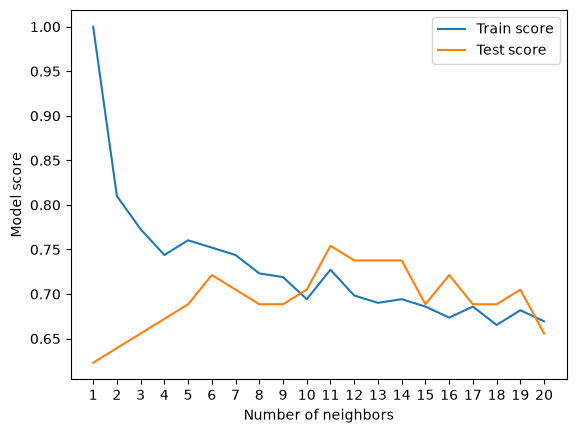

In [25]:
# 繪製訓練集與測試集準確率隨鄰居數量的變化
plt.plot(neighbors, train_scores, label="Train score")
plt.plot(neighbors, test_scores, label="Test score")
plt.xticks(np.arange(1, 21, 1))
plt.xlabel("Number of neighbors")
plt.ylabel("Model score")
plt.legend()

print(f"Maximum KNN score on the test data: {max(test_scores)*100:.2f}%")

n_neighbors=11 表現最佳，但即使調參後，KNN 準確率仍明顯低於
Logistic Regression 與 Random Forest，
因此後續改用 RandomizedSearchCV，為這兩個模型自動搜尋最佳超參數組合。

## 超參數調校：使用RandomizedSearchCV

In [26]:
# Logistic Regression的超參數搜尋範圍
log_reg_grid = {"C": np.logspace(-4, 4, 20), # 正則化強度
                "solver": ["liblinear"]}

# Random Forest的超參數範圍
rf_grid = {"n_estimators": np.arange(10, 1000, 50),
           "max_depth": [None, 3, 5, 10],
           "min_samples_split": np.arange(2, 20, 2),
           "min_samples_leaf": np.arange(1, 20, 2)}

### 調校 Logistic Regression

In [27]:
np.random.seed(42)
rs_log_reg = RandomizedSearchCV(
    LogisticRegression(),
    param_distributions=log_reg_grid, # 要嘗試的參數範圍
    cv=5,                             # 交叉驗證
    n_iter=20,                        # 隨機抽樣20種組合來試
    verbose=True                      # 訓練過程中，印出詳細進度訊息
    )

# 搜尋最佳參數並訓練最終模型
rs_log_reg.fit(X_train, y_train) 

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=LogisticRegression(), n_iter=20,
                   param_distributions={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                                        'solver': ['liblinear']},
                   verbose=True)

In [28]:
# 查看搜尋出的最佳參數組合
rs_log_reg.best_params_ 

{'solver': 'liblinear', 'C': np.float64(0.23357214690901212)}

In [29]:
 # 用測試集驗證最終模型表現
rs_lr_score = rs_log_reg.score(X_test,y_test)
rs_lr_score

0.8852459016393442

### 調校 Random Forest

In [30]:
np.random.seed(42)
rs_rf = RandomizedSearchCV(RandomForestClassifier(),
                           param_distributions=rf_grid,
                           cv=5,
                           n_iter=20,
                           verbose=True)
rs_rf.fit(X_train, y_train);

Fitting 5 folds for each of 20 candidates, totalling 100 fits


In [31]:
rs_rf.best_params_

{'n_estimators': np.int64(210),
 'min_samples_split': np.int64(4),
 'min_samples_leaf': np.int64(19),
 'max_depth': 3}

In [32]:
rs_rf_score = rs_rf.score(X_test, y_test)
rs_rf_score

0.8688524590163934

兩個模型調參後準確率皆略有提升，而 Logistic Regression 表現較佳。<br>
接下來改用 GridSearchCV 進一步微調。

## 使用 GridSearchCV 進一步調校 Logistic Regression

與 RandomizedSearchCV 隨機抽樣不同，GridSearchCV 會測試所有可能的參數組合。

In [33]:
log_reg_grid = {"C": np.logspace(-4,4,20),
               "solver": ["liblinear"]}
gs_log_reg = GridSearchCV(
    LogisticRegression(),
    param_grid=log_reg_grid,
    cv=5,
    verbose=True)
# 搜尋最佳參數並訓練最終模型
gs_log_reg.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                         'solver': ['liblinear']},
             verbose=True)

In [34]:
# 查看最佳參數組合
gs_log_reg.best_params_ 

{'C': np.float64(0.23357214690901212), 'solver': 'liblinear'}

In [35]:
# 用測試集驗證表現
gs_lr_score = gs_log_reg.score(X_test,y_test) 
gs_lr_score

0.8852459016393442

因候選組合只有20種，結果與 RandomizedSearchCV 相同。

Logistic Regression 在三種調參方式下分數一致，且在三個分類器中表現最佳，將作為後續深入評估的主要模型。

## 比較原始模型與調參後模型的準確率。

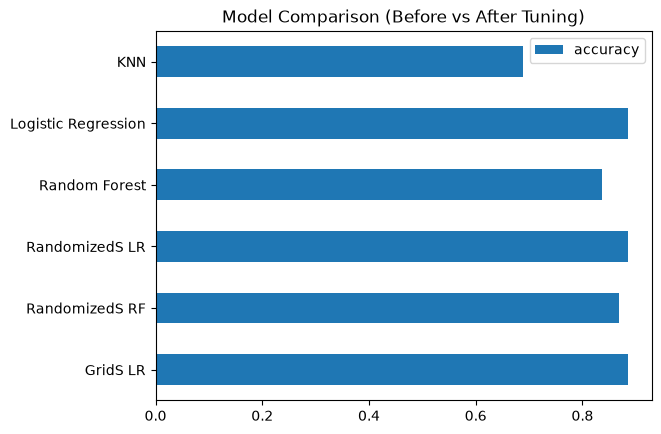

In [36]:
model_scores.update([('RandomizedS LR', rs_lr_score), 
                     ('RandomizedS RF',rs_rf_score),
                     ('GridS LR',gs_lr_score)])
model_compare2 = pd.DataFrame(model_scores, index=["accuracy"])
model_compare2.T.iloc[::-1].plot.barh(title="Model Comparison (Before vs After Tuning)");


## 模型評估：ROC曲線與AUC分數

用訓練好的模型對測試集進行預測，作為後續各項評估指標的基礎。

In [37]:
y_preds = gs_log_reg.predict(X_test)
y_preds

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

ROC曲線呈現真陽性率與假陽性率的權衡，評估模型區分兩類的能力。<br>
AUC越接近1代表表現越好，0.5代表等同隨機猜測

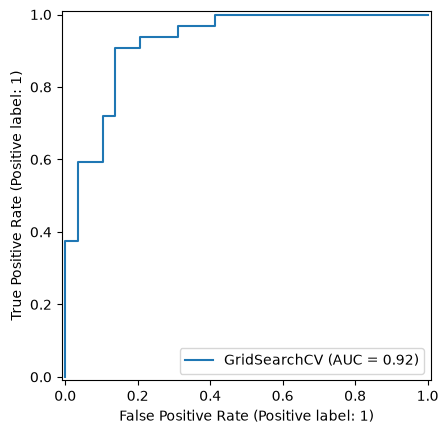

In [38]:
plt.style.use('default')

RocCurveDisplay.from_estimator(
    estimator=gs_log_reg, # 已經訓練完成（fitted）的機器學習模型
    X = X_test,  # 用於測試的特徵資料
    y = y_test,   # 用於測試的實際標籤
);

模型明顯優於隨機猜測（AUC > 0.5），但尚未達到滿分1.0，仍有進步空間。

### 混淆矩陣

呈現模型預測正確與錯誤的分布情形。

In [39]:
# 傳入實際標籤（true labels）和預測標籤（predicted labels）
print(confusion_matrix(y_test, y_preds))

[[25  4]
 [ 3 29]]


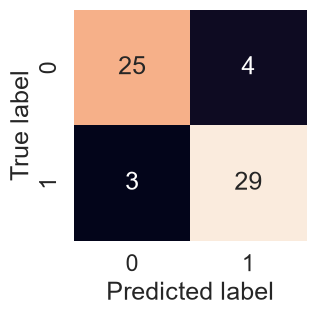

In [40]:
# 用 Seaborn 的 heatmap 繪製混淆矩陣
sns.set_theme(font_scale=1.5)

def plot_conf_mat(y_test,y_preds):
    fig, ax = plt.subplots(figsize=(3, 3))
    ax = sns.heatmap(confusion_matrix(y_test, y_preds),
                     annot=True, # 格子裡「顯示數字」
                     cbar=False) # 旁邊「不要顯示顏色刻度條」
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
plot_conf_mat(y_test, y_preds)

模型在兩類的錯誤數量相近：<br>
4筆假陰性（實際有病卻預測沒病）、3筆假陽性（實際沒病卻預測有病）。

### 分類報告 Classification Report

使用 `classification_report()` 計算每個類別的precision、recall、f1-score

指標說明：

- Support：計算該指標所用的樣本數
- Accuracy：整體準確率
- Macro avg：不考慮類別樣本數差異的平均值
- Weighted avg：依樣本數加權的平均值，樣本數多的類別影響較大

本次資料集類別分布平衡，兩種平均值差異應不大。

In [41]:
print(classification_report(y_test, y_preds))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



### 交叉驗證評估

用最佳參數重新建立模型，以5折交叉驗證分別計算accuracy、
precision、recall、f1的平均值，取得比單次切分更穩健的評估結果。

In [42]:
gs_log_reg.best_params_ # 查看GridSearchCV找到的最佳參數

{'C': np.float64(0.23357214690901212), 'solver': 'liblinear'}

In [43]:
# 用最佳參數重新建立一個乾淨的模型
clf = LogisticRegression(C=0.23357214690901212,
                         solver="liblinear")

In [44]:
# 5折交叉驗證計算準確率 (Cross-validated accuracy score)
cv_acc = cross_val_score(clf,
                         X,
                         y,
                         cv=5, # 5折交叉驗證
                         scoring="accuracy")
cv_acc

array([0.81967213, 0.90163934, 0.8852459 , 0.88333333, 0.75      ])

In [45]:
cv_acc = np.mean(cv_acc) # 取5次結果的平均值
cv_acc

np.float64(0.8479781420765027)

In [46]:
# 5折交叉驗證計算precision
cv_precision = np.mean(
    cross_val_score(clf, X, y, cv=5, scoring="precision")
    )
cv_precision

np.float64(0.8215873015873015)

In [47]:
# 5折交叉驗證計算recall
cv_recall = np.mean(
    cross_val_score(clf, X, y, cv=5, scoring="recall")
    )
cv_recall

np.float64(0.9272727272727274)

In [48]:
# 5折交叉驗證計算f1-score
cv_f1 = np.mean(cross_val_score(clf, X, y, cv=5, scoring="f1"))
cv_f1

np.float64(0.8705403543192143)

Recall（92.7%）明顯高於Precision（82.2%），
代表模型較少漏診有心臟病的病人，這在醫療情境下是理想的特性。

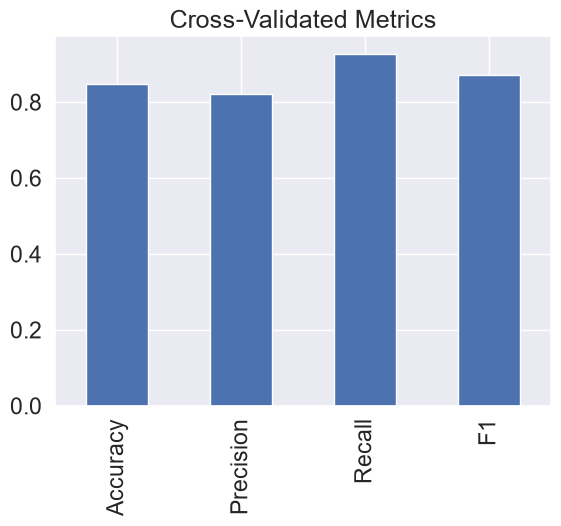

In [49]:
# 將四個交叉驗證指標整合成長條圖
cv_metrics = pd.DataFrame(
    {"Accuracy": cv_acc,
     "Precision": cv_precision,
     "Recall": cv_recall,
     "F1": cv_f1},
     index=[0]
)
cv_metrics.T.plot.bar(title="Cross-Validated Metrics", legend=False);

## 特徵重要性

Logistic Regression 使用 `coef_` 屬性計算特徵重要性，
即公式中每個特徵對應的權重，數值絕對值越大代表影響力越大，
正值為正相關、負值為負相關。

In [50]:
# 重新訓練最終模型
clf.fit(X_train, y_train)

LogisticRegression(C=0.23357214690901212, solver='liblinear')

In [51]:
# 查看每個特徵對應的權重
clf.coef_

array([[ 0.00369922, -0.9042409 ,  0.67472826, -0.0116134 , -0.00170364,
         0.04787688,  0.33490198,  0.02472938, -0.63120406, -0.5759095 ,
         0.47095141, -0.65165348, -0.69984208]])

In [52]:
# 將係數與特徵名稱配對
features_dict = dict(zip(df.columns, list(clf.coef_[0])))
features_dict

{'age': np.float64(0.0036992207735222936),
 'sex': np.float64(-0.9042409027676933),
 'cp': np.float64(0.6747282591013247),
 'trestbps': np.float64(-0.011613401311995881),
 'chol': np.float64(-0.001703643974904055),
 'fbs': np.float64(0.04787688089306608),
 'restecg': np.float64(0.3349019821325941),
 'thalach': np.float64(0.024729382907772574),
 'exang': np.float64(-0.6312040609811942),
 'oldpeak': np.float64(-0.5759095019287949),
 'slope': np.float64(0.4709514064291035),
 'ca': np.float64(-0.6516534774104941),
 'thal': np.float64(-0.6998420760932893)}

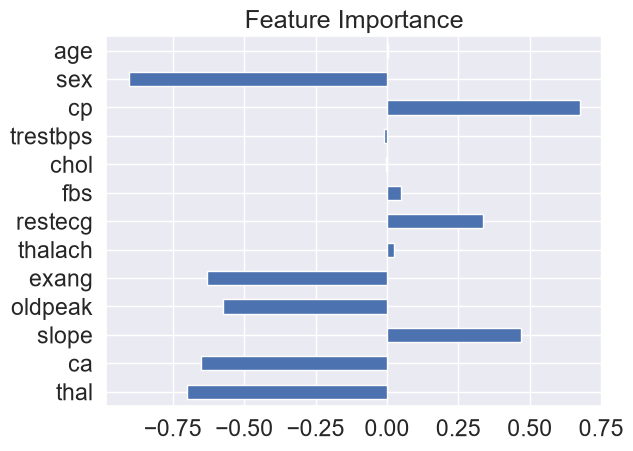

In [53]:
# 用長條圖呈現每個特徵的係數大小
features_df = pd.DataFrame(features_dict, index=[0])
features_df.T.iloc[::-1].plot.barh(title="Feature Importance", legend=False);

從圖表觀察，胸痛類型（cp）、休息狀態心電圖（restecg）、
運動高峰ST段斜率（slope）對模型影響最強；

性別（sex）影響力最弱。

## 結論

模型未達到最初設定的95%準確率目標（最佳結果約88.5%），
但這不代表沒有價值——已知目前模型與資料集的表現上限，
可作為後續改進方向的基礎。